In [ ]:
#Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score

In [ ]:
#Loading data. (renamed csv files for simplicity)
#May need to edit path to where datais stored on your computer.
test = 'churn_testing.csv'
#------------------------------------------------------------
test_df = pd.read_csv(test)
#Extras
pred_df = test_df.copy()


In [17]:
# ---------------- User input for subscription churn predictions

In [ ]:
#Displays columns and their data types
pred_df.dtypes

CustomerID            int64
Age                   int64
Gender               object
Tenure                int64
Usage Frequency       int64
Support Calls         int64
Payment Delay         int64
Subscription Type    object
Contract Length      object
Total Spend           int64
Last Interaction      int64
Churn                 int64
dtype: object

In [ ]:
#Drops insignificant column
pred_df = pred_df.drop(columns=['CustomerID'], errors='ignore')
pred_df.isnull().sum()

Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [ ]:
#Dropping all null values & verifying they're deleted
pred_df = pred_df.dropna()
pred_df.isnull().sum()

Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [ ]:
#Encoding gender nominally
ohe = OneHotEncoder(drop='first', sparse_output=False)
gender_encoded = ohe.fit_transform(pred_df[['Gender']])

gender_cols = ohe.get_feature_names_out(['Gender'])
gender_df = pd.DataFrame(gender_encoded, columns=gender_cols, index=pred_df.index)

pred_df = pd.concat(
    [pred_df.drop(columns='Gender'), gender_df],
    axis=1
)

In [ ]:
#Encoding subscription type and contract length ordinally
ord_cols = ['Subscription Type', 'Contract Length']
ord_levels = [
    ['Basic', 'Standard', 'Premium'],
    ['Monthly', 'Quarterly', 'Annual']
]

oe = OrdinalEncoder(categories=ord_levels)
pred_df[ord_cols] = oe.fit_transform(pred_df[ord_cols])

#Setting target & feature variables
X = pred_df.drop(columns='Churn')
y = pred_df['Churn']


In [ ]:
#Initiating train test split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.18,
    stratify=y_temp,
    random_state=42
)
from imblearn.under_sampling import RandomUnderSampler
#Verifies training data is balanced
rus = RandomUnderSampler(random_state=42)
X_train_bal, y_train_bal = rus.fit_resample(X_train, y_train)

Train Accuracy: 0.996
Validation Accuracy: 0.996
Test Accuracy: 0.994

Classification Report on Gradient Boosting:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      5083
           1       1.00      0.99      0.99      4574

    accuracy                           0.99      9657
   macro avg       0.99      0.99      0.99      9657
weighted avg       0.99      0.99      0.99      9657



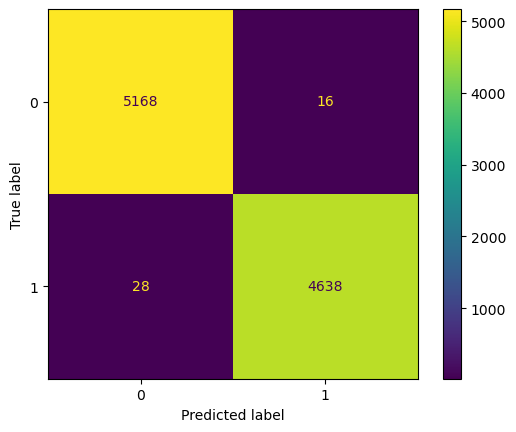

In [ ]:
#Building machine model
gb = GradientBoostingClassifier(
    n_estimators=120,
    learning_rate=0.08,
    max_depth=3,
    random_state=42
)

gb.fit(X_train_bal, y_train_bal)
#Creating accuracy variables to showcase evaluation results & classification report
val_preds = gb.predict(X_val)
train_acc = gb.score(X_train_bal, y_train_bal)
val_acc = gb.score(X_val, y_val)
test_acc = gb.score(X_test, y_test)

print("Train Accuracy:", round(train_acc, 3))
print("Validation Accuracy:", round(val_acc, 3))
print("Test Accuracy:", round(test_acc, 3))

y_test_pred = gb.predict(X_test)

print("\nClassification Report on Gradient Boosting:")
print(classification_report(y_test, y_test_pred))
#Showcasing confusion matrix to show identification accuracy
cm = confusion_matrix(y_val, val_preds)
ConfusionMatrixDisplay(cm).plot()
plt.show()

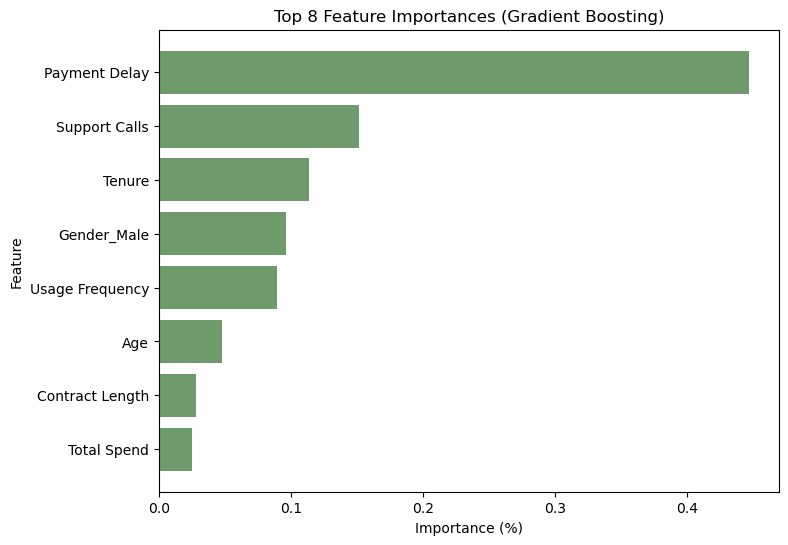

In [36]:
importances = gb.feature_importances_
features = X_train.columns

# Create dataframe and sort
feat_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Keep only top 8 features
top_feat_df = feat_df.head(8)

# Plot
plt.figure(figsize=(8,6))
plt.barh(top_feat_df["feature"], top_feat_df["importance"], color="#6e9a6c")
plt.gca().invert_yaxis()
plt.xlabel("Importance (%)")
plt.ylabel("Feature")
plt.title("Top 8 Feature Importances (Gradient Boosting)")
plt.show()

In [28]:
def predict_churn(user_input_dict):
    user_df = pd.DataFrame([user_input_dict])

    # Matches training columns exactly
    user_df = user_df.reindex(columns=X_train.columns, fill_value=0)

    prob = gb.predict_proba(user_df)[0][1]
    #Returns churn risk probability in percent form
    return round(prob * 100, 2)

In [32]:
print("\n--- Customer Churn Prediction ---\n")

user = {
    "Age": float(input("Enter your age: ")),
    
    "Gender": 1 if input("Enter Sex (Female/Male): ").lower() == "female" else 0,
    
    "Tenure": float(input("How many months has it been since you subscribed? ")),
    
    "Usage Frequency": float(input("Throughout your total usage, how often have you found yourself using the platform? ")),
    
    "Support Calls": float(input("How many times have you needed to call support? (0 if none) ")),
    
    "Payment Delay": float(input("How many days have you delayed your payment to the subscription? (0 if none) ")),
    
    "Subscription Type": {
        "standard": 0,
        "premium": 1,
        "basic": 2
    }[input("Enter Subscription Type (Standard/Premium/Basic): ").lower()],
    
    "Contract Length": {
        "annual": 0,
        "quarterly": 1,
        "monthly": 2
    }[input("Enter Contract Length (Annual/Quarterly/Monthly): ").lower()],
    
    "Total Spend": float(input("Enter Total Spend ($): ")),
    
    "Last Interaction": float(input("Enter Days Since Last Interaction: "))
}



--- Customer Churn Prediction ---



In [ ]:
prob = predict_churn(user)

print("\n--------------------------")
print(f"Churn Risk: {prob}%")
#Assessment messages are influenced by feature importance graph by gradient boosting
if prob > 80:
    print(f"We have calculated a high risk of churn. There is a {prob}% likelihood that this is hurting your finances.\n Ultimately, we recommend you should end the subscription, especially if you tend to have payment delays and call support often")
elif prob < 80 and prob > 49:
    print(f"According to our calculations, you have a {prob}% churn risk. You may be better off leaving the subscription, especially if you often have payment delays, call support, and/or low usage frequency.")
elif prob < 49:
    print(f"Overall, you have a relatively low churn risk at {prob}%. This indicates that you may be using your subscription reasonably enough to continue without hurting finances.")


--------------------------
Churn Risk: 97.5%
We have calculated a high risk of churn. There is a 97.5% likelihood that this is hurting your finances. Ultimately, we recommend you should end the subscription.


In [ ]:
#Verifying class balance regarding churn feature
print(y_train.value_counts(normalize=True))

Churn
0    0.546237
1    0.453763
Name: proportion, dtype: float64


In [31]:
#For deployment usage
test_df.to_pickle("churn_testing.pkl")